# Manifold Alignment with a Ridge Regression Decoder

This project will do a couple of things...

- A manifold is a generalization of the Euclidean space. We will use the assumption that for all of our sessions, there is a lower dimensional neural latent space that affects the data. We will use PCA (there are other non-linear methods like ISOMAP and UMAP that we could use too) to reduce dimensionality to 10 dimensions (arbitrary number).
-  With these manifold coordinates, we will find the optimal global alignment for every manifold that we can map to. We will use iterative procedures that basically align each new manifold with the mean of the previous manifolds.
- After this, we will make a decoder that decodes our manifold data to our intended movement direction. We will use normal manifolds and fitted manifolds. We will use ridge regression as a simple decoder, with the input being the last N points in our manifold.
- We will use a decoder for without manifold fitting, and with manifold fitting. That would be the best.

## Setup

In [5]:
import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pynwb import NWBHDF5IO
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
from scipy.linalg import orthogonal_procrustes
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

DATA_DIR  = os.path.join('.', 'data', '001201', 'sub-Monkey-N')
nwb_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.nwb')])
print(f'Found {len(nwb_files)} sessions total')

# --- Hyperparameters ---
BIN_SIZE_S   = 0.004
TARGET_BIN_S = 0.050
DOWNSAMPLE   = int(round(TARGET_BIN_S / BIN_SIZE_S))   # = 12
N_DIMS       = 40
N_LAGS       = 1
TRAIN_FRAC   = 0.8
MAX_SESSIONS = 312   # cap at 250 — sessions beyond this show heavy electrode drift
GPA_POINTS   = 5000
GPA_MAX_ITER = 500
GPA_TOL      = 1e-7
RNG          = np.random.default_rng(42)

# --- SBP normalisation before PCA ---
# 'none'   : raw SBP fed into PCA
# 'demean' : subtract per-session channel mean before PCA (removes DC drift)
# 'zscore' : subtract mean and divide by std before PCA
SBP_NORM = 'zscore'   # <-- change to compare: 'none' | 'demean' | 'zscore'

nwb_files = nwb_files[:MAX_SESSIONS]
print(f'Using first {len(nwb_files)} sessions  |  SBP_NORM={SBP_NORM}')

TRAIN_SESSIONS = int(len(nwb_files) * TRAIN_FRAC)
TEST_SESSIONS  = len(nwb_files) - TRAIN_SESSIONS
print(f'Train sessions: {TRAIN_SESSIONS}  |  Test sessions: {TEST_SESSIONS}')

def downsample_mean(x, factor):
    n = (len(x) // factor) * factor
    return x[:n].reshape(-1, factor).mean(axis=1)

def downsample_mean_2d(X, factor):
    n = (len(X) // factor) * factor
    return X[:n].reshape(-1, factor, X.shape[1]).mean(axis=1)

def normalize_2d(X, mode):
    """Normalize (T, C) array per channel. Returns (normalized, loc, scale)."""
    loc   = X.mean(axis=0)
    scale = X.std(axis=0) if mode == 'zscore' else np.ones(X.shape[1])
    if mode == 'none':   return X.copy(), loc, scale
    if mode == 'demean': return X - loc,  loc, scale
    return (X - loc) / (scale + 1e-8), loc, scale


Found 312 sessions total
Using first 312 sessions  |  SBP_NORM=zscore
Train sessions: 249  |  Test sessions: 63


## Step 1 — Load & Downsample, then Global PCA

First pass: load and downsample all sessions to 50ms bins, subsample a chunk from each to fit one global PCA. Second pass: project every session through that shared PCA so PC1 always means the same thing across all 312 sessions.

In [6]:
PCA_SUBSAMPLE = 2000   # bins from session 0 used to fit PCA

# --- Pass 1: load and downsample all sessions ---
print('Pass 1: loading and downsampling all sessions...')
all_sbp_ds    = []
all_vel_ds    = []
session_dates = []
session_files = []

for i, fname in enumerate(nwb_files):
    path = os.path.join(DATA_DIR, fname)
    with NWBHDF5IO(path, 'r') as io:
        nwb     = io.read()
        sbp_raw = nwb.analysis['SpikingBandPower'].data[:] / 0.25
        tgt_raw = nwb.analysis['index_position'].data[:].ravel()
        date    = nwb.session_start_time.date()

    sbp_ds = downsample_mean_2d(sbp_raw, DOWNSAMPLE)
    tgt_ds = downsample_mean(tgt_raw,    DOWNSAMPLE)
    sbp_norm, _, _ = normalize_2d(sbp_ds, SBP_NORM)

    all_sbp_ds.append(sbp_norm)
    all_vel_ds.append(tgt_ds)
    session_dates.append(date)
    session_files.append(fname)

    if (i + 1) % 50 == 0 or i == 0:
        print(f'  [{i+1}/{len(nwb_files)}] {fname}  bins={sbp_ds.shape[0]}')

session_dates = np.array(session_dates)

# --- Fit PCA on session 0 only ---
# Session 0 is the fixed reference frame. All other sessions are projected
# into it, so manifold coordinates are anchored to one consistent geometry.
# GPA then corrects for the rotational misalignment introduced by electrode drift.
sbp_s0 = all_sbp_ds[0]
n_sub  = min(PCA_SUBSAMPLE, len(sbp_s0))
s0_subsample = sbp_s0[RNG.choice(len(sbp_s0), size=n_sub, replace=False)]

print(f'\nFitting PCA on session 0 ({session_files[0]}, {n_sub} bins, SBP_NORM={SBP_NORM})...')
global_pca = PCA(n_components=N_DIMS)
global_pca.fit(s0_subsample)
print(f'  Explained variance ratio: {global_pca.explained_variance_ratio_.round(3)}')
print(f'  Total variance explained: {global_pca.explained_variance_ratio_.sum():.3f}')

# --- Pass 2: project all sessions through session-0 PCA ---
print('\nPass 2: projecting all sessions through session-0 PCA...')
session_manifolds = []
session_targets   = []

for sbp_norm, tgt_ds in zip(all_sbp_ds, all_vel_ds):
    session_manifolds.append(global_pca.transform(sbp_norm))
    session_targets.append(tgt_ds)

print(f'Done. Example manifold shape: {session_manifolds[0].shape}')


Pass 1: loading and downsampling all sessions...
  [1/312] sub-Monkey-N_ses-20200127_ecephys.nwb  bins=2304
  [50/312] sub-Monkey-N_ses-20210122_ecephys.nwb  bins=2388
  [100/312] sub-Monkey-N_ses-20210706_ecephys.nwb  bins=1876
  [150/312] sub-Monkey-N_ses-20211025_ecephys.nwb  bins=1890
  [200/312] sub-Monkey-N_ses-20220415_obj-y4c3g5_ecephys.nwb  bins=2072
  [250/312] sub-Monkey-N_ses-20220921_obj-1k78ex8_ecephys.nwb  bins=1893
  [300/312] sub-Monkey-N_ses-20230502_ecephys.nwb  bins=2097

Fitting PCA on session 0 (sub-Monkey-N_ses-20200127_ecephys.nwb, 2000 bins, SBP_NORM=zscore)...
  Explained variance ratio: [0.414 0.09  0.033 0.022 0.017 0.014 0.012 0.011 0.01  0.01  0.01  0.01
 0.009 0.009 0.009 0.008 0.008 0.008 0.008 0.008 0.008 0.007 0.007 0.007
 0.007 0.007 0.007 0.006 0.006 0.006 0.006 0.006 0.006 0.006 0.006 0.005
 0.005 0.005 0.005 0.005]
  Total variance explained: 0.843

Pass 2: projecting all sessions through session-0 PCA...
Done. Example manifold shape: (2304, 40)


## Diagnostic — Compare: Raw SBP vs Global PCA Manifold, Within-Session

Two questions answered side by side on session 0:
1. Does raw 50ms SBP decode velocity well?
2. Does the global PCA manifold decode velocity as well?

If #2 is much worse than #1, PCA is discarding velocity-relevant signal.

Within-session R²  —  session 0  (sub-Monkey-N_ses-20200127_ecephys.nwb)
  SBP_NORM=zscore  |  PCA fitted on session 0
  Raw SBP (96 channels)  : 0.5011
  Session-0 PCA (40 dims): 0.3800

>> PCA preserves most of the signal — problem is cross-session transfer.

Sweeping N_DIMS (5 to 95, step 5) — PCA refit on session 0 each time...
  N_DIMS=  5  →  R²=0.2785
  N_DIMS= 10  →  R²=0.3088
  N_DIMS= 15  →  R²=0.3017
  N_DIMS= 20  →  R²=0.3222
  N_DIMS= 25  →  R²=0.3235
  N_DIMS= 30  →  R²=0.3585
  N_DIMS= 35  →  R²=0.3482
  N_DIMS= 40  →  R²=0.3800
  N_DIMS= 45  →  R²=0.3850
  N_DIMS= 50  →  R²=0.3985
  N_DIMS= 55  →  R²=0.3886
  N_DIMS= 60  →  R²=0.3901
  N_DIMS= 65  →  R²=0.3825
  N_DIMS= 70  →  R²=0.3751
  N_DIMS= 75  →  R²=0.3700
  N_DIMS= 80  →  R²=0.4218
  N_DIMS= 85  →  R²=0.4168
  N_DIMS= 90  →  R²=0.4304
  N_DIMS= 95  →  R²=0.4187


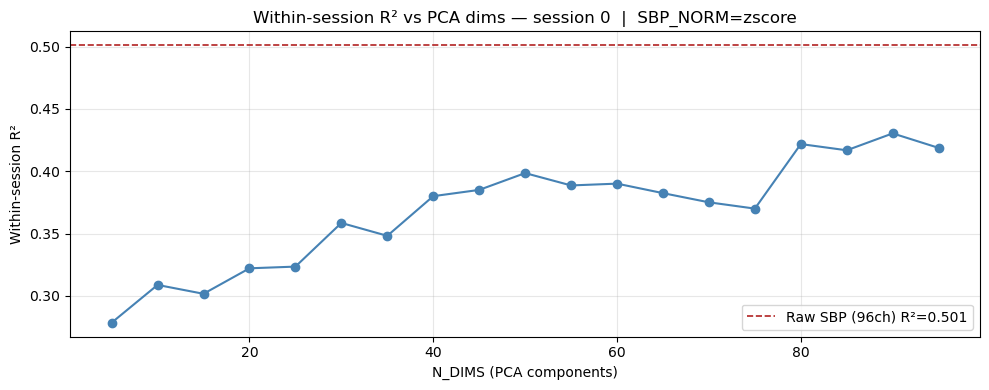

Saved: manifold_ndims_sweep.png


In [7]:
def within_session_r2(X, y, n_lags, xgb_params):
    X_lag = np.array([X[t - n_lags:t].ravel() for t in range(n_lags, len(X))])
    y_lag = y[n_lags:]
    n_train = int(len(X_lag) * 0.8)
    m = XGBRegressor(**xgb_params)
    m.fit(X_lag[:n_train], y_lag[:n_train])
    return r2_score(y_lag[n_train:], m.predict(X_lag[n_train:]))

xgb_params = dict(n_estimators=300, learning_rate=0.05, max_depth=4,
                  subsample=0.8, colsample_bytree=0.8,
                  random_state=42, verbosity=0, n_jobs=-1)

sbp_s0 = all_sbp_ds[0]
vel_s0 = session_targets[0]
man_s0 = session_manifolds[0]

r2_raw = within_session_r2(sbp_s0, vel_s0, N_LAGS, xgb_params)
r2_pca = within_session_r2(man_s0, vel_s0, N_LAGS, xgb_params)

print(f'Within-session R²  —  session 0  ({session_files[0]})')
print(f'  SBP_NORM={SBP_NORM}  |  PCA fitted on session 0')
print(f'  Raw SBP (96 channels)  : {r2_raw:.4f}')
print(f'  Session-0 PCA ({N_DIMS} dims): {r2_pca:.4f}')

if r2_pca < r2_raw * 0.5:
    print('\n>> PCA is losing most of the velocity signal — consider more N_DIMS.')
else:
    print('\n>> PCA preserves most of the signal — problem is cross-session transfer.')

# Sweep N_DIMS in steps of 5, refitting PCA on session 0 each time
print(f'\nSweeping N_DIMS (5 to 95, step 5) — PCA refit on session 0 each time...')
dims_sweep = list(range(5, 96, 5))
r2_sweep   = []
for d in dims_sweep:
    pca_d  = PCA(n_components=d).fit(s0_subsample)
    coords = pca_d.transform(sbp_s0)
    r2     = within_session_r2(coords, vel_s0, N_LAGS, xgb_params)
    r2_sweep.append(r2)
    print(f'  N_DIMS={d:3d}  →  R²={r2:.4f}')

# Plot the sweep
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dims_sweep, r2_sweep, marker='o', lw=1.5, color='steelblue')
ax.axhline(r2_raw, color='firebrick', linestyle='--', lw=1.2, label=f'Raw SBP (96ch) R²={r2_raw:.3f}')
ax.set_xlabel('N_DIMS (PCA components)')
ax.set_ylabel('Within-session R²')
ax.set_title(f'Within-session R² vs PCA dims — session 0  |  SBP_NORM={SBP_NORM}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('manifold_ndims_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: manifold_ndims_sweep.png')


## Step 2 — Generalized Procrustes Analysis (GPA) on Subsampled Point Clouds

Each session's PCA coordinate frame is arbitrary — axes can be rotated or sign-flipped relative to other sessions. GPA finds one orthogonal rotation per session that maps it into a shared reference frame.

Rather than aligning single mean vectors (which have no orientation), we subsample `GPA_POINTS` random time bins from each session to get a representative point cloud `(GPA_POINTS, N_DIMS)`, then run iterative Procrustes on those clouds:

1. Initialize the reference as the subsampled cloud from session 0 (mean-centered, unit-scaled).
2. For each session, find the orthogonal `R` minimising `‖X_i R - reference‖²` and apply it.
3. Update the reference to the mean of all aligned clouds.
4. Repeat until the reference stops changing.

The rotation found on the subsampled cloud is then applied to every time bin in the full session.

In [8]:
def mean_center(X):
    return X - X.mean(axis=0)

def unit_scale(X):
    s = np.sqrt((X ** 2).sum())
    return X / s if s > 0 else X

def subsample(M, n, rng):
    idx = rng.choice(len(M), size=n, replace=False)
    return M[idx]

# Normalize each session manifold
normed = [unit_scale(mean_center(M)) for M in session_manifolds]

# Cap GPA_POINTS to the shortest session so all clouds are the same shape
min_len    = min(len(M) for M in normed)
n_pts      = min(GPA_POINTS, min_len)
print(f'Shortest session: {min_len} bins  →  using {n_pts} points per cloud')

clouds = [subsample(M, n_pts, RNG) for M in normed]

# Iterative GPA
reference = unit_scale(mean_center(clouds[0].copy()))
rotations = [np.eye(N_DIMS)] * len(normed)

for iteration in range(GPA_MAX_ITER):
    aligned_clouds = []
    for i, cloud in enumerate(clouds):
        R, _ = orthogonal_procrustes(cloud, reference)
        rotations[i] = R
        aligned_clouds.append(cloud @ R)

    new_reference = unit_scale(mean_center(np.mean(aligned_clouds, axis=0)))
    change = np.linalg.norm(new_reference - reference)
    reference = new_reference

    if (iteration + 1) % 10 == 0:
        print(f'  GPA iter {iteration+1:3d}  |  change = {change:.2e}')
    if change < GPA_TOL:
        print(f'  Converged at iteration {iteration+1}')
        break
else:
    print(f'  Warning: did not converge in {GPA_MAX_ITER} iters (final change={change:.2e})')

# Apply rotations to full time-series
aligned_manifolds = [M @ rotations[i] for i, M in enumerate(normed)]
print(f'\nGPA done.  Aligned shape example: {aligned_manifolds[0].shape}')

Shortest session: 1735 bins  →  using 1735 points per cloud
  GPA iter  10  |  change = 5.62e-02
  GPA iter  20  |  change = 2.56e-02
  GPA iter  30  |  change = 1.62e-02
  GPA iter  40  |  change = 1.15e-02
  GPA iter  50  |  change = 8.89e-03
  GPA iter  60  |  change = 7.51e-03
  GPA iter  70  |  change = 6.54e-03
  GPA iter  80  |  change = 5.60e-03
  GPA iter  90  |  change = 4.82e-03
  GPA iter 100  |  change = 4.22e-03
  GPA iter 110  |  change = 3.63e-03
  GPA iter 120  |  change = 3.17e-03
  GPA iter 130  |  change = 2.87e-03
  GPA iter 140  |  change = 2.63e-03
  GPA iter 150  |  change = 2.44e-03
  GPA iter 160  |  change = 2.30e-03
  GPA iter 170  |  change = 2.11e-03
  GPA iter 180  |  change = 1.95e-03
  GPA iter 190  |  change = 1.83e-03
  GPA iter 200  |  change = 1.73e-03
  GPA iter 210  |  change = 1.66e-03
  GPA iter 220  |  change = 1.60e-03
  GPA iter 230  |  change = 1.55e-03
  GPA iter 240  |  change = 1.51e-03
  GPA iter 250  |  change = 1.47e-03
  GPA iter 260 

## Step 3 — Cross-Session XGBoost Decoder

One decoder is trained on the first `TRAIN_SESSIONS` sessions (concatenated) and tested on every remaining session. Done separately for unaligned and GPA-aligned manifolds. XGBoost is used because it captures nonlinear neural-to-kinematic relationships that ridge regression misses.

In [9]:
def build_lag_features(M, n_lags):
    return np.array([M[t - n_lags:t].ravel() for t in range(n_lags, len(M))])

def build_dataset(manifolds, targets, n_sessions, n_lags):
    X_parts, y_parts = [], []
    for M, tgt in zip(manifolds[:n_sessions], targets[:n_sessions]):
        X = build_lag_features(M, n_lags)
        X_parts.append(X)
        y_parts.append(tgt[n_lags:])
    return np.vstack(X_parts), np.concatenate(y_parts)

xgb_params = dict(n_estimators=300, learning_rate=0.05, max_depth=4,
                  subsample=0.8, colsample_bytree=0.8,
                  random_state=42, verbosity=0, n_jobs=-1)

print(f'Training on first {TRAIN_SESSIONS} sessions ({int(TRAIN_FRAC*100)}%)...')
X_train_u, y_train_u = build_dataset(normed,            session_targets, TRAIN_SESSIONS, N_LAGS)
X_train_a, y_train_a = build_dataset(aligned_manifolds, session_targets, TRAIN_SESSIONS, N_LAGS)
print(f'  Train set shape: {X_train_u.shape}')

print('Fitting XGBoost decoders...')
decoder_u = XGBRegressor(**xgb_params)
decoder_a = XGBRegressor(**xgb_params)
decoder_u.fit(X_train_u, y_train_u)
decoder_a.fit(X_train_a, y_train_a)
print('  Done.')

print(f'\nTesting on last {TEST_SESSIONS} sessions ({100 - int(TRAIN_FRAC*100)}%)...')
r2_unaligned, r2_aligned, test_dates = [], [], []

for i in range(TRAIN_SESSIONS, len(normed)):
    y   = session_targets[i][N_LAGS:]
    X_u = build_lag_features(normed[i],            N_LAGS)
    X_a = build_lag_features(aligned_manifolds[i], N_LAGS)
    r2_unaligned.append(r2_score(y, decoder_u.predict(X_u)))
    r2_aligned.append(  r2_score(y, decoder_a.predict(X_a)))
    test_dates.append(session_dates[i])

r2_unaligned = np.array(r2_unaligned)
r2_aligned   = np.array(r2_aligned)
test_dates   = np.array(test_dates)

print(f'Mean R² unaligned : {np.nanmean(r2_unaligned):.4f}')
print(f'Mean R² aligned   : {np.nanmean(r2_aligned):.4f}')
print(f'Sessions tested   : {len(r2_unaligned)}')

Training on first 249 sessions (80%)...
  Train set shape: (513472, 40)
Fitting XGBoost decoders...
  Done.

Testing on last 63 sessions (20%)...
Mean R² unaligned : 0.0831
Mean R² aligned   : -0.0045
Sessions tested   : 63


## Step 4 — Results: Cross-Session R² Over Time

Each bar is one held-out test session (sessions 51–312), ordered by date. The decoder was trained once on the first 50 sessions and never retrained. If manifold alignment helps, the orange bars should be consistently higher than the blue ones — especially for sessions far in the future from the training window.

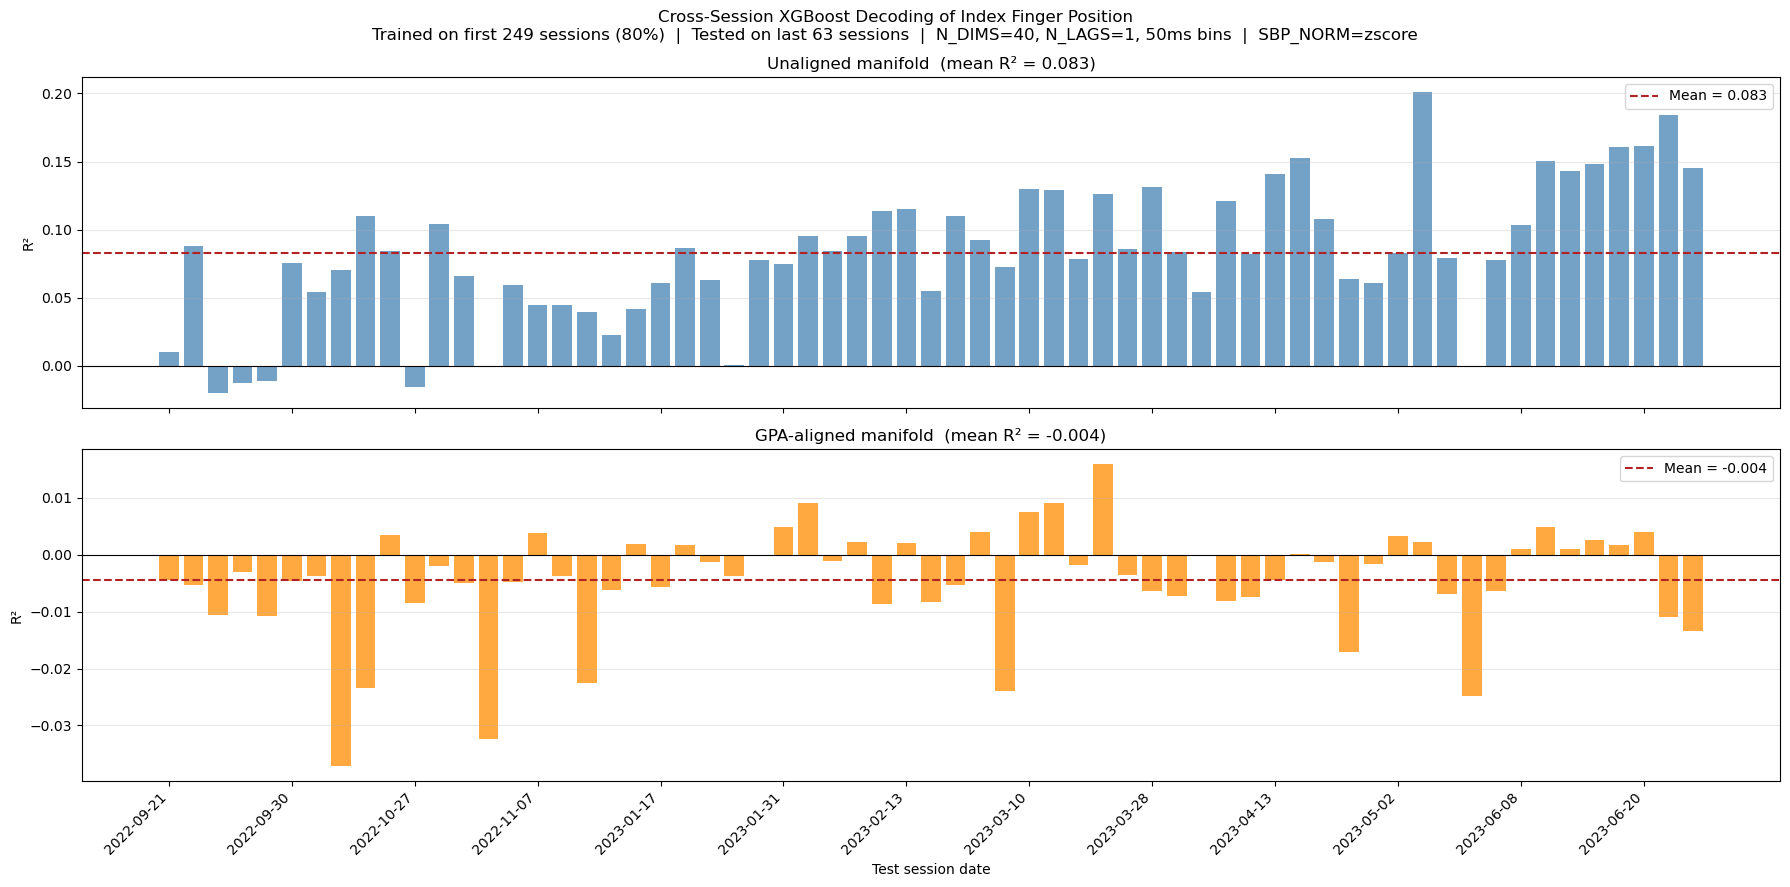

Saved: manifold_alignment_r2.png


In [10]:
mean_u = np.nanmean(r2_unaligned)
mean_a = np.nanmean(r2_aligned)

fig, axes = plt.subplots(2, 1, figsize=(18, 9), sharex=True)

for ax, r2_vals, mean_val, color, title in [
    (axes[0], r2_unaligned, mean_u, 'steelblue',
     f'Unaligned manifold  (mean R² = {mean_u:.3f})'),
    (axes[1], r2_aligned,   mean_a, 'darkorange',
     f'GPA-aligned manifold  (mean R² = {mean_a:.3f})'),
]:
    x = np.arange(len(r2_vals))
    ax.bar(x, np.clip(r2_vals, -1, None), color=color, alpha=0.75, width=0.8)
    ax.axhline(mean_val, color='firebrick', linewidth=1.5, linestyle='--',
               label=f'Mean = {mean_val:.3f}')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('R²')
    ax.set_title(title)
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3)

n = len(test_dates)
tick_step   = max(1, n // 12)
tick_pos    = np.arange(0, n, tick_step)
tick_labels = [str(test_dates[i]) for i in tick_pos]
axes[1].set_xticks(tick_pos)
axes[1].set_xticklabels(tick_labels, rotation=45, ha='right')
axes[1].set_xlabel('Test session date')

plt.suptitle(
    f'Cross-Session XGBoost Decoding of Index Finger Position\n'
    f'Trained on first {TRAIN_SESSIONS} sessions ({int(TRAIN_FRAC*100)}%)  |  '
    f'Tested on last {TEST_SESSIONS} sessions  |  '
    f'N_DIMS={N_DIMS}, N_LAGS={N_LAGS}, {int(TARGET_BIN_S*1000)}ms bins  |  SBP_NORM={SBP_NORM}',
    fontsize=12
)
plt.tight_layout()
plt.savefig('manifold_alignment_r2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: manifold_alignment_r2.png')
